In [4]:
import os, sys
os.chdir(os.path.expanduser('~/work/galactic_dynamics'))
sys.path.insert(0, 'JAM')
sys.path.insert(0, 'Axi_Schwarzschild/Schwarzschild')
print('CWD:', os.getcwd())


CWD: /home/haitong/work/galactic_dynamics


No is_good column in the data, set all bins to good.
(41,) (41, 618)
Reff: 54.34711014664929
17 17
0.04 154.88


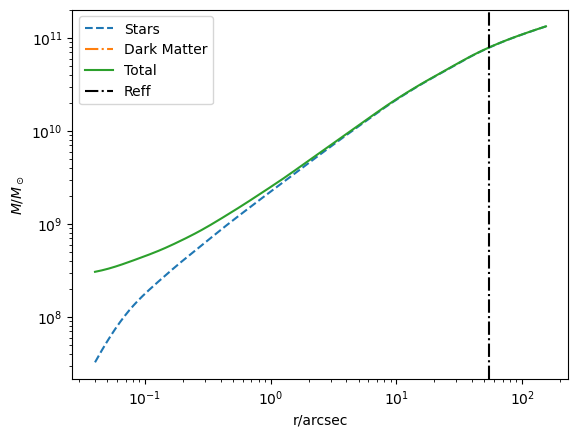

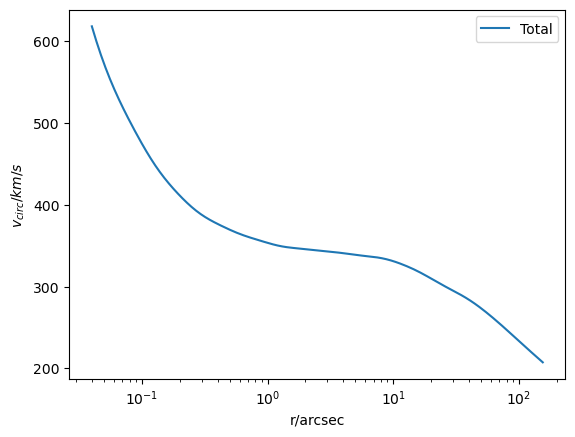

In [3]:
import numpy as np

import matplotlib.pyplot as plt
from jam_fit import JamInput
from jam_fit.plot import plot_enclosed_mass

jam_input = JamInput('JAM/configs/NGC4621-mock2/hist.yaml')
radi, stars_masses, dm_masses, total_masses = plot_enclosed_mass(jam_input, None)

# plt.axvline(0.29, color='r', linestyle='-.', label='Rsoi')
# print(np.min(sigma_pot), np.max(sigma_pot))
print(np.min(jam_input.sigma), np.max(jam_input.sigma))
# plt.xlim([0.1*np.min(sigma_pot), 10*np.max(sigma_pot)])
# plt.ylim([2E-2,2E6])
plt.show()

import astropy.constants as const
import astropy.units as u
radi_pc = (radi*u.arcsec*jam_input.dist*u.Mpc/u.radian).to(u.pc)
vcirc = np.sqrt(total_masses*u.Msun*const.G/(radi_pc)).to(u.km/u.s).value
plt.plot(radi, vcirc, label='Total')
plt.xscale('log')
plt.xlabel('r/arcsec')
plt.ylabel(r'$v_{circ}/km/s$')
plt.legend()
plt.show()


data/processed/NGC4552 ../results/JAM/NGC4552/oasis_test
{'h4_corr': False, 'use_hist': False}
[0.51370772 1.02287293 8.80541267 0.60992017]
chi2: 2278.5801926233453


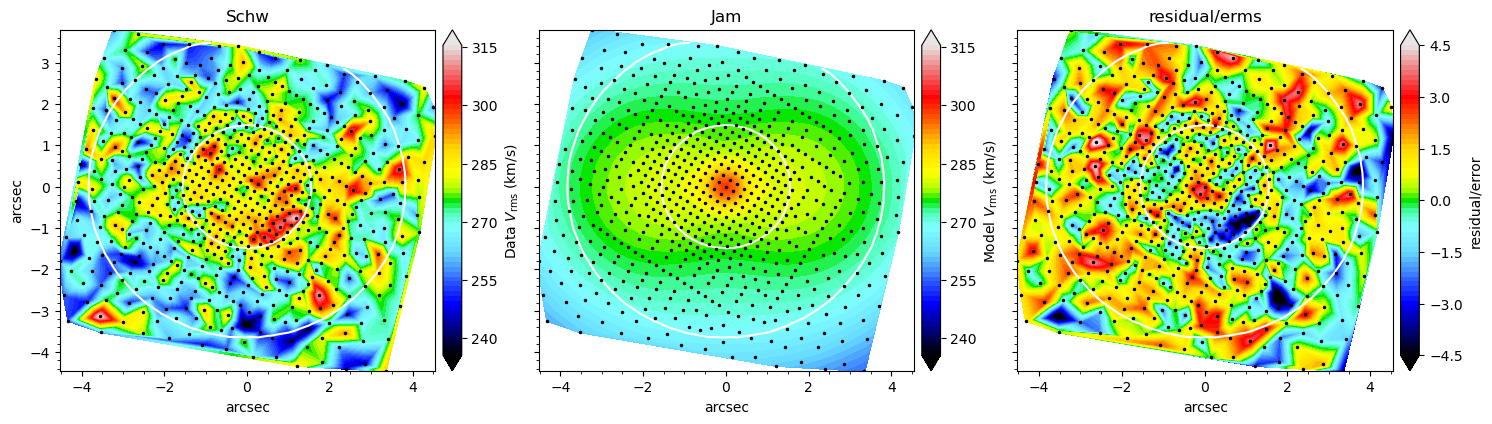

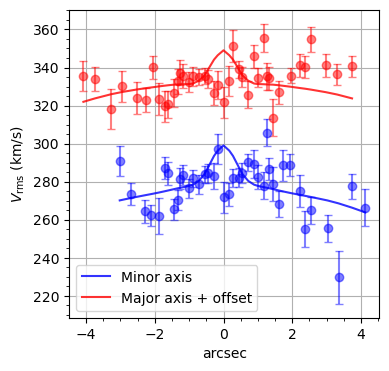

data/processed/NGC5846 results/JAM/NGC5846/oasis_test
{'h4_corr': False, 'use_hist': False}
[0.66786895 1.07986557 9.28528847 0.69538359]
chi2: 505.31062634836314


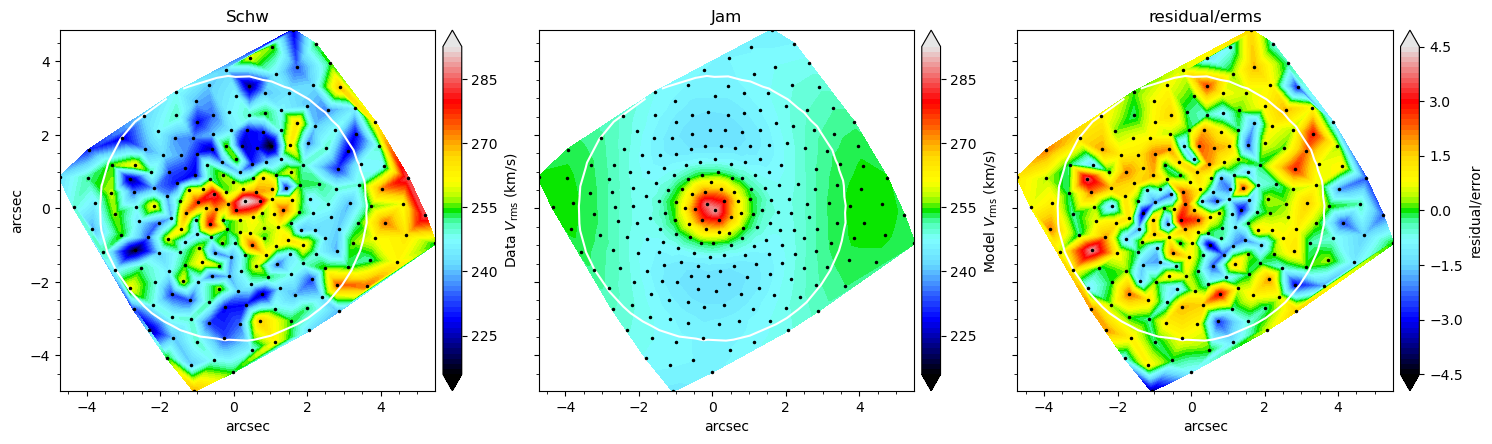

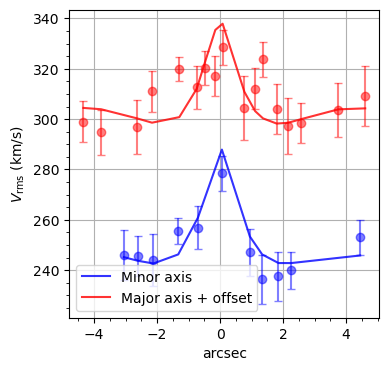

In [12]:
from jam_fit import JamInput, jam_model
from jam_fit.plot import plot_kinematics, plot_kin1d
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# model_list = [
#     'results/JAM/NGC4621-mock2/i75-sph-hist',
#     'results/JAM/NGC4621-mock2/i75-sph2-hist',
#     'results/JAM/NGC4621-mock2/i75-sph3-hist',
#     'results/JAM/NGC4621-mock2/i75-sph-fixaniso-hist',
# ]

model_list = [
    # 'results/JAM/NGC4621-mock-iso/i75-cyl-hist',
    # 'results/JAM/NGC4621-mock-iso/i75-sph-hist',
    'results/JAM/NGC4552/oasis_test',
    'results/JAM/NGC5846/oasis_test',
    ]
for work_dir in model_list:
    work_dir = Path(work_dir)
    jam_config = JamInput(work_dir)
    print(jam_config.input_dir, jam_config.work_dir)
    print(jam_config.config_dict['kinematic_settings'])
    kwargs = jam_config.get_kwargs()
    xbin = kwargs['xbin']
    ybin = kwargs['ybin']

    pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
    print(pars)
    pars_dict = jam_config.get_pars(pars)
    out_model = jam_model(pars_dict, **kwargs)
    plot_kinematics(jam_config, out_model, relative_residual=True, resrange=4.5)
    plt.show()
    plot_kin1d(jam_config, out_model)
    plt.show()


CWD: /home/haitong/work/galactic_dynamics
No is_good column in the data, set all bins to good.
(41,) (41, 618)
input/NGC4621-mock-iso ../results/JAM/NGC4621-mock-iso/i75-cyl-hist
8.44988317010032 0.4572269209751024
{'q': 0.141, 'ratio': np.float64(0.9952501246784453), 'lg_mbh': np.float64(8.44988317010032), 'lg_ml': np.float64(0.4572269209751024), 'f_dm': 0.0, 'lg_rb': 3.0, 'sigma1': 0.36, 'sigma2': 0.92, 'weight1': 0.76, 'ratio_inf': 0.615, 'lg_ra': 1.425, 'lg_al': 0.3, 'lg_ml_inf': 0.462}
chi2: 132.03644022023423


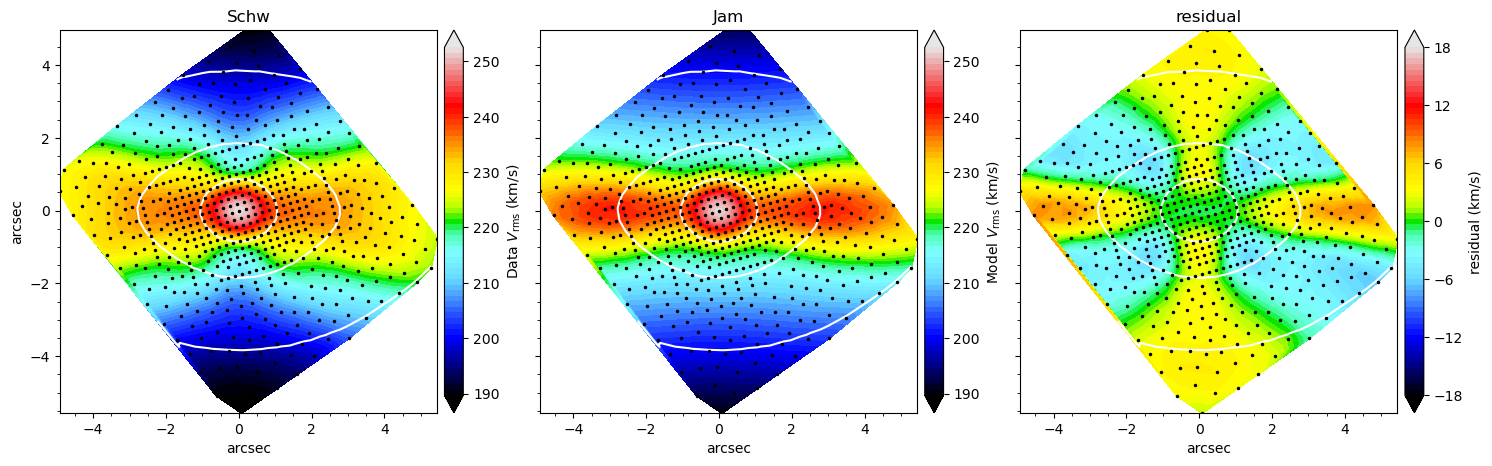

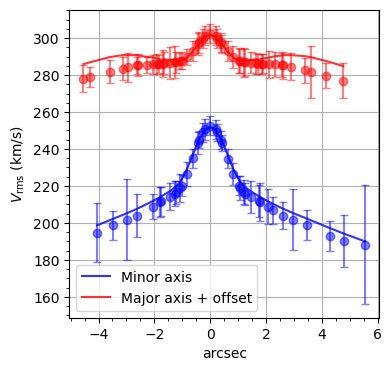

8.43 0.4485
chi2: 219.3285707207253


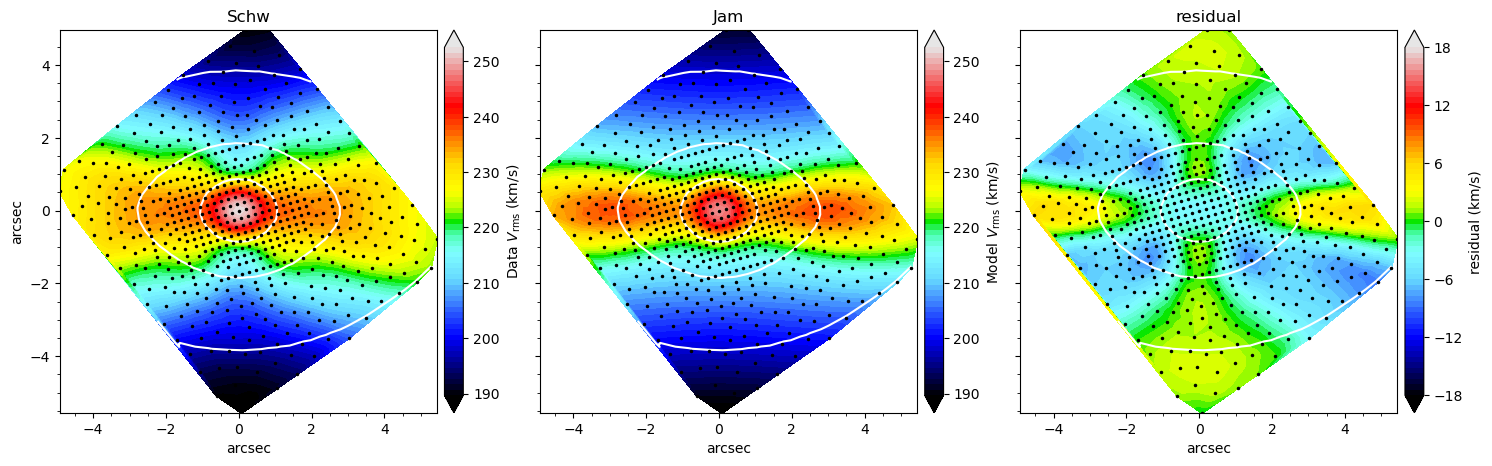

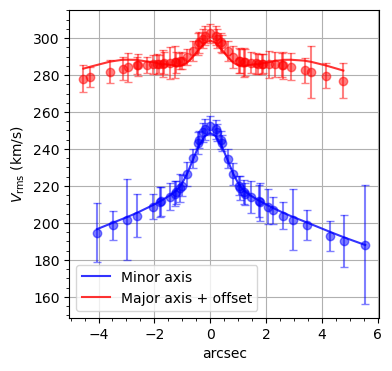

In [3]:
import os, sys
os.chdir(os.path.expanduser('~/work/galactic_dynamics'))
sys.path.insert(0, 'JAM')
sys.path.insert(0, 'Axi_Schwarzschild/Schwarzschild')
print('CWD:', os.getcwd())

from jam_fit import JamInput, jam_model
from jam_fit.plot import plot_kinematics, plot_kin1d
import jampy as jam
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# config_path = 'results/JAM/NGC4621/schwmock-i75-sph2/config.yaml'
# config_path = 'results/JAM/NGC4621-mock2/i75-sph3-hist/config.yaml'
# work_dir = Path('results/JAM/NGC4621-mock2/i75-cyl-fixaniso2-hist')
work_dir = Path('results/JAM/NGC4621-mock-iso/i75-cyl-hist')
# jam_config = JamInput('JAM/configs/NGC4621-mock2/hist.yaml', h4_corr=True)

jam_config = JamInput(work_dir)
# jam_config_hist = JamInput(config_path, use_hist=True, h4_corr=False)

# plt.scatter(jam_config.rms, jam_config_hist.rms, s=10)
# plt.plot([min(jam_config.rms), max(jam_config.rms)], [min(jam_config.rms), max(jam_config.rms)], 'k--')
# plt.xlabel('RMS (no hist)')
# plt.ylabel('RMS (hist)')
# plt.axis('equal')
# plt.show()

print(jam_config.input_dir, jam_config.work_dir)
kwargs = jam_config.get_kwargs()
xbin = kwargs['xbin']
ybin = kwargs['ybin']

pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
# pars = [1.00000002, 8.65870274, 0.07575157, 0.50000009]
# pars = [1.000000002, 8.7274669686, 0.4388457214665, 0.83618640862]
# [1.28402724 8.49173113 0.3017789  0.94162766]
# pars = [1.61189567, 8.83060316, 0.20861146, 0.83347379]

resrange = 18
pars_dict = jam_config.get_pars(pars)
print(pars_dict['lg_mbh'], pars_dict['lg_ml'])
print(pars_dict)
out_model = jam_model(pars_dict, **kwargs)
plot_kinematics(jam_config, out_model, relative_residual=False, resrange=resrange)
plt.show()
plot_kin1d(jam_config, out_model)
plt.show()
# plot_kinematics(jam_config, out_model, relative_residual=True)
# plt.show()

pars_dict = jam_config.get_pars(pars)
pars_dict['lg_mbh'] = 8.43
pars_dict['lg_ml'] = 0.4485
print(pars_dict['lg_mbh'], pars_dict['lg_ml'])
out_model = jam_model(pars_dict, **kwargs)
plot_kinematics(jam_config, out_model, relative_residual=False, resrange=resrange)
plt.show()
plot_kin1d(jam_config, out_model)
plt.show()
# plot_kinematics(jam_config, out_model, relative_residual=True)
# plt.show()



No is_good column in the data, set all bins to good.
(41,) (41, 618)
No is_good column in the data, set all bins to good.
(41,) (41, 618)
logistic radius: 1.0
Sphere of influence radius in arcsec: 0.13811478518386094
No is_good column in the data, set all bins to good.
(41,) (41, 618)
logistic radius: 1.0
Sphere of influence radius in arcsec: 0.4496694634303869
No is_good column in the data, set all bins to good.
(41,) (41, 618)
logistic radius: 0.1393584398372967
Sphere of influence radius in arcsec: 0.14492196270210975
No is_good column in the data, set all bins to good.
(41,) (41, 618)
logistic radius: 10.0
Sphere of influence radius in arcsec: 0.7245067940775484
No is_good column in the data, set all bins to good.
(41,) (41, 618)
logistic radius: 26.6072505979881
Sphere of influence radius in arcsec: 0.5205878110967993
No is_good column in the data, set all bins to good.
(41,) (41, 618)
1.1263214565865252
logistic radius: 26.6072505979881
Sphere of influence radius in arcsec: 0.508

(0.1, 35)

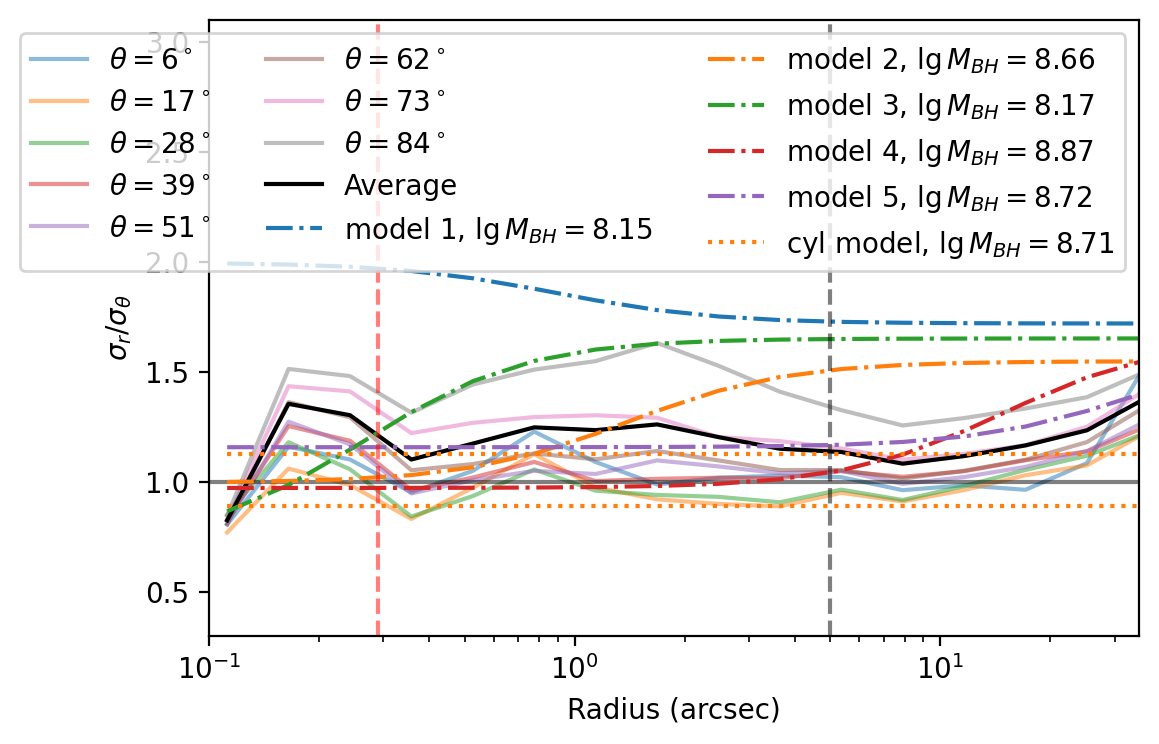

In [5]:
from jam_fit.utils import logistic, sigma_ratio_logistic
from shared_utils.jam_schw_compare import plot_anisotropy
from jam_fit import JamInput, jam_model
from schwarzpy.model import read_nn_mer, read_ap, plot_vel_ellipsoid
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

work_dir = Path('results/JAM/NGC4621-mock2/i75-cyl-hist')
jam_config = JamInput(work_dir)
aperture_file = jam_config.input_dir / 'aperture_o.dat'
nn_mer_file = jam_config.input_dir / 'nn_mer.out'

# work_dir = 'input/NGC4621-mock-gh'
# nn_mer_file = work_dir + '/nn_mer.out'

rplot, avg_anisotropy = plot_anisotropy(nn_mer_file, km_in_arcsec=2.7e15, direction='theta')

model_list = [
    'results/JAM/NGC4621-mock2/i75-sph-hist',
    'results/JAM/NGC4621-mock2/i75-sph2-hist',
    'results/JAM/NGC4621-mock2/i75-sph3-hist',
    # 'results/JAM/NGC4621-mock2/i75-sph-fixaniso-gh',
    'results/JAM/NGC4621-mock2/i75-sph-fixaniso-hist',
    'results/JAM/NGC4621-mock2/i75-sph-fixaniso2-hist',

    # 'results/JAM/NGC4621-mock-iso/i75-sph-hist',
    
    # 'results/JAM/NGC4621-mock2/i75-sph4-hist',
    # 'results/JAM/NGC4621-mock2/i75-sph3-h4
    # 'results/JAM/NGC4621-mock2/i75-sph3-sig'
]

# fit the logistic function to the anisotropy profile, and plot the best-fit curve
def objective_func(pars, r, ratio_obs):
    ratio0, ratio1, lg_r0, lg_alpha = pars
    ratio_model = sigma_ratio_logistic(r, ratio0, ratio1, 10**lg_r0, 10**lg_alpha)
    return np.sum((ratio_model - ratio_obs)**2)

# from scipy.optimize import minimize
# init_pars = [0.7, 1.5, 1, 2]
# r_max = np.inf
# rplot_fit = rplot[rplot<r_max]
# avg_anisotropy_fit = avg_anisotropy[rplot<r_max]
# result = minimize(objective_func, init_pars, args=(rplot_fit, avg_anisotropy_fit), bounds=[(0, 3), (0, 3), (-1, 2), (-1, 0.3)])
# pars_fit = result.x
# # pars_fit = [0.97273419, 1.6541483, 1., 0.3]
# print('Best-fit parameters:', pars_fit)
# print('Best_fit parameters in terms of anisotropy:', 1/pars_fit[0], 1/pars_fit[1])
# best_fit_ratio = sigma_ratio_logistic(rplot, pars_fit[0], pars_fit[1], 10**pars_fit[2], 10**pars_fit[3])
# plt.plot(rplot, best_fit_ratio, 'r.-', label=f'logi fit')

import astropy.units as u
import astropy.constants as const

# plot the anisotropy profile of JAM models
for i, work_dir in enumerate(model_list):
    work_dir = Path(work_dir)
    config_path = work_dir / 'config.yaml'
    jam_config = JamInput(config_path)
    pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
    pars_dict = jam_config.get_pars(pars)
    logi_anisotropy = sigma_ratio_logistic(rplot, 1/pars_dict['ratio'], 1/pars_dict['ratio_inf'], 10**pars_dict['lg_ra'], 2)
    # label = f'JAM-sph model {i+1}, $\\lg M_{{BH}}={pars_dict["lg_mbh"]:.2f}$'
    label = f'model {i+1}, $\\lg M_{{BH}}={pars_dict["lg_mbh"]:.2f}$'
    plt.plot(rplot, logi_anisotropy, '-.', color=f'C{i}', label=label)

    print('logistic radius:', 10**pars_dict['lg_ra'])
    mbh = 10**pars_dict['lg_mbh'] * const.M_sun

    sigma = 225 * u.km/u.s
    r_soi = const.G*mbh/sigma**2
    distMpc = 17.78 * u.Mpc
    r_soi_arcsec = (r_soi/distMpc*u.radian).to(u.arcsec).value
    # plt.axvline(r_soi_arcsec, color=f'C{i}', linestyle=':')
    print('Sphere of influence radius in arcsec:', r_soi_arcsec)

cyl_model_list = [
    'results/JAM/NGC4621-mock2/i75-cyl-fixaniso2-hist',
    # 'results/JAM/NGC4621-mock-iso/i75-cyl-hist',
]

for i, work_dir in enumerate(cyl_model_list, 1):
    work_dir = Path(work_dir)
    config_path = work_dir / 'config.yaml'
    jam_config = JamInput(config_path)
    pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
    pars_dict = jam_config.get_pars(pars)
    print(1/pars_dict['ratio'])
    label = f'cyl model, $\\lg M_{{BH}}={pars_dict["lg_mbh"]:.2f}$'
    plt.plot(rplot, np.full_like(rplot, 1/pars_dict['ratio']), ':', color=f'C{i}', label=label)
    plt.plot(rplot, np.full_like(rplot, pars_dict['ratio']), ':', color=f'C{i}')

    print('logistic radius:', 10**pars_dict['lg_ra'])
    mbh = 10**pars_dict['lg_mbh'] * const.M_sun

    sigma = 225 * u.km/u.s
    r_soi = const.G*mbh/sigma**2
    distMpc = 17.78 * u.Mpc
    r_soi_arcsec = (r_soi/distMpc*u.radian).to(u.arcsec).value
    # plt.axvline(r_soi_arcsec, color=f'C{i}', linestyle=':')
    print('Sphere of influence radius in arcsec:', r_soi_arcsec)

plt.legend(ncol=3)
plt.ylim(0.3, 3.1)
plt.axvline(0.29, color='r', linestyle='--',alpha=0.5, label='Rsoi')
plt.axvline(5., color='k', linestyle='--',alpha=0.5, label='OASIS FOV')
plt.xlim(0.1, 35)
# plt.axhline(1/0.75)



No is_good column in the data, set all bins to good.
(41,) (41, 618)


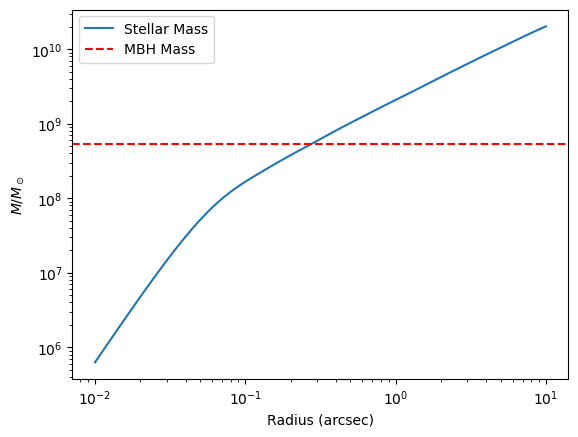

In [10]:
from jam_fit.utils import stellar_mass
from jampy.mge.mge_radial_mass import mge_radial_mass

# config_path = 'results/JAM/NGC4621-mock2/i75-sph3-hist/config.yaml'
work_dir = Path('results/JAM/NGC4621-mock2/i75-sph-fixaniso2-hist')
jam_config = JamInput(work_dir)
pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
pars_dict = jam_config.get_pars(pars)

r = np.geomspace(0.01, 10, 100)
mass = stellar_mass(r, jam_config, pars_dict)
mbh = 10**pars_dict['lg_mbh']
plt.plot(r, mass, label='Stellar Mass')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius (arcsec)')
plt.ylabel(r'$M/M_\odot$')
plt.axhline(mbh, color='r', linestyle='--', label='MBH Mass')
plt.legend()
plt.show()


In [12]:
import astropy.units as u
import astropy.constants as const

sigma = 225 * u.km/u.s
mbh = 10**8.43 * const.M_sun
r_soi = const.G*mbh/sigma**2
distMpc = 17.78 * u.Mpc
print('Sphere of influence radius:', r_soi.to(u.pc))
print('Sphere of influence radius in arcsec:', (r_soi/distMpc*u.radian).to(u.arcsec))

Sphere of influence radius: 22.86630818985279 pc
Sphere of influence radius in arcsec: 0.2652707889969841 arcsec


CWD: /home/haitong/work/galactic_dynamics
No is_good column in the data, set all bins to good.
(41,) (41, 618)
1.1263214565865252


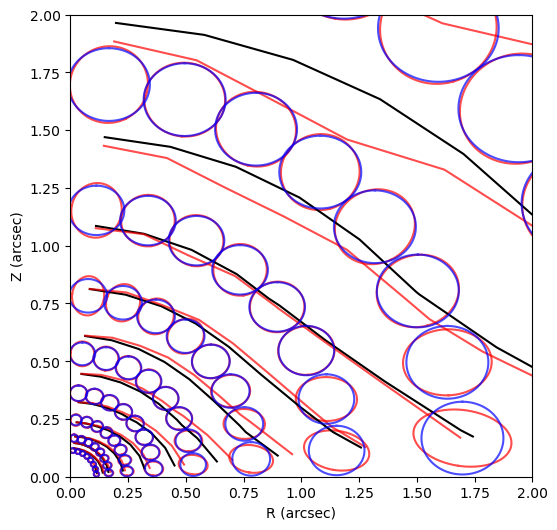

In [22]:
import os, sys
os.chdir(os.path.expanduser('~/work/galactic_dynamics'))
sys.path.insert(0, 'JAM')
sys.path.insert(0, 'Axi_Schwarzschild/Schwarzschild')
print('CWD:', os.getcwd())

from jam_fit.utils import sigma_ratio_logistic
from jam_fit import JamInput, jam_model
from shared_utils.jam_schw_compare import plot_2D_anisotropy, plot_2D_anisotropy_logi, plot_2D_anisotropy_const
from schwarzpy.model import read_nn_mer, read_ap, plot_vel_ellipsoid
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
# from schwarzpy.model import plot_2D_anisotropy

work_dir = Path('results/JAM/NGC4621-mock2/i75-cyl-fixaniso2-hist')
jam_config = JamInput(work_dir)
aperture_file = jam_config.input_dir / 'aperture_o.dat'
nn_mer_file = jam_config.input_dir / 'nn_mer.out'
pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
pars_dict = jam_config.get_pars(pars)

aperture = 2
fig, ax, rplot, thplot = plot_2D_anisotropy(nn_mer_file, aperture_file, aperture=aperture, distMpc=jam_config.dist, color='r', alpha=0.7)

# nn_mer_file = jam_config.input_dir / 'nn_mer-me-001.out'
# fig, ax, rplot, thplot = plot_2D_anisotropy(nn_mer_file, aperture_file, aperture=aperture, distMpc=jam_config.dist, fig=fig, ax=ax, color='b', alpha=0.7)
# logi_anisotropy = sigma_ratio_logistic(rplot, 1/pars_dict['ratio'], 1/pars_dict['ratio_inf'], 10**pars_dict['lg_ra'], 2)
# plot_2D_anisotropy_logi(rplot, thplot, 1/pars_dict['ratio'], 1/pars_dict['ratio_inf'], 10**pars_dict['lg_ra'], 2, fig=fig, ax=ax)
print(1/pars_dict['ratio'])
plot_2D_anisotropy_const(rplot, thplot, 1/pars_dict['ratio'], align='cyl', fig=fig, ax=ax)
# plt.legend()
# plt.xlim(0,2)
# plt.ylim(0,2)
plt.show()


No is_good column in the data, set all bins to good.
(41,) (41, 618)


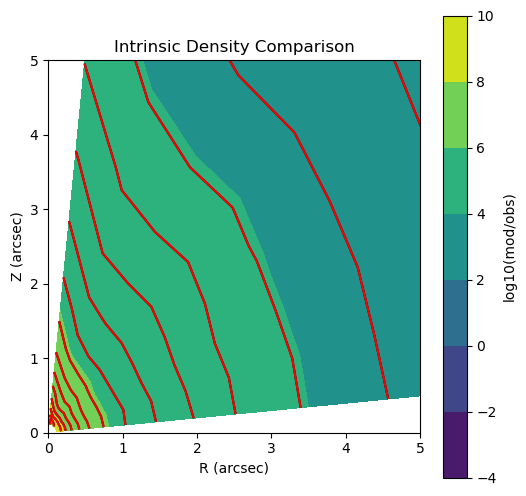

In [5]:
from shared_utils.jam_schw_compare import plot_2D_density
from jam_fit import JamInput
import matplotlib.pyplot as plt
from pathlib import Path

work_dir = Path('results/JAM/NGC4621-mock2/i75-sph-fixaniso2-hist')
jam_config = JamInput(work_dir)
aperture_file = jam_config.input_dir / 'aperture_o.dat'
nn_mer_file = jam_config.input_dir / 'nn_mer.out'

plot_2D_density(nn_mer_file, aperture_file, distMpc=jam_config.dist, aperture=5)



CWD: /home/haitong/work/galactic_dynamics
No is_good column in the data, set all bins to good.
(41,) (41, 618)


/home/haitong/work/galactic_dynamics/shared_utils/jam_schw_compare.py:406: RuntimeWarning: invalid value encountered in sqrt
  jam_moments['phi1'] = np.sqrt(jam_moments['phi2'] - jam_moments['phi2sig'])


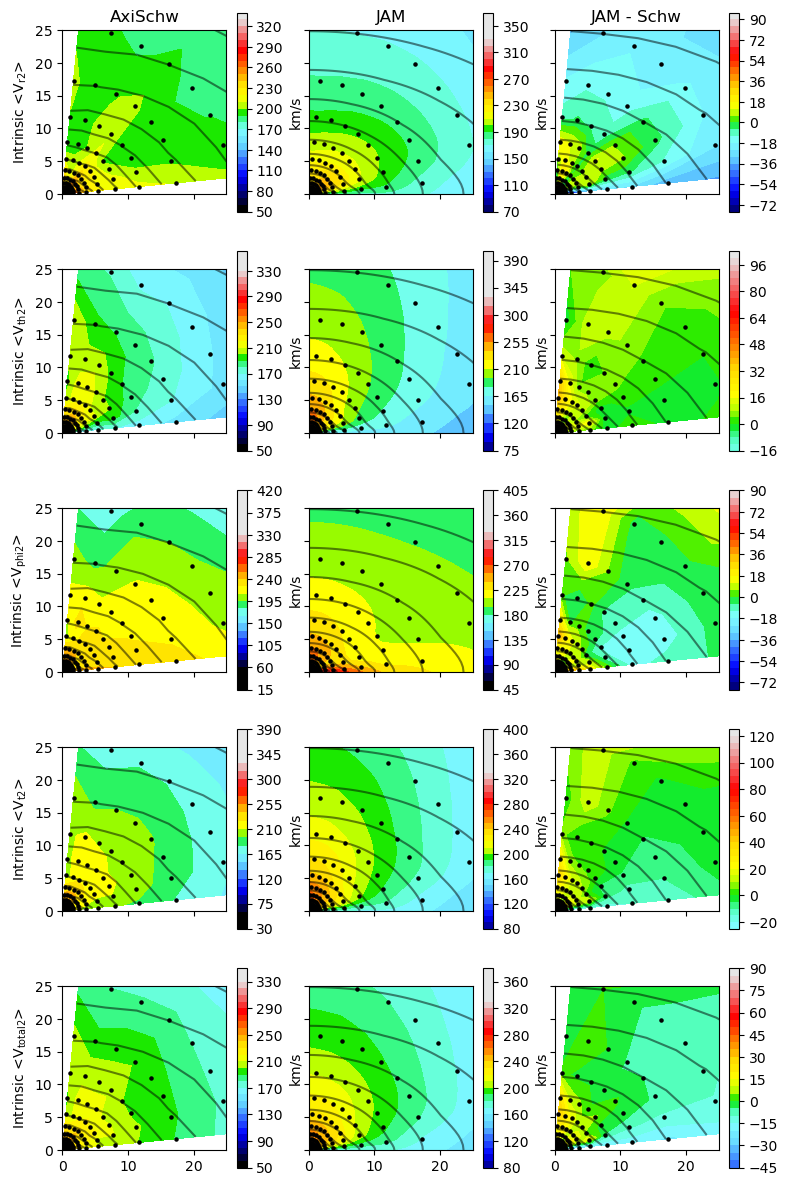

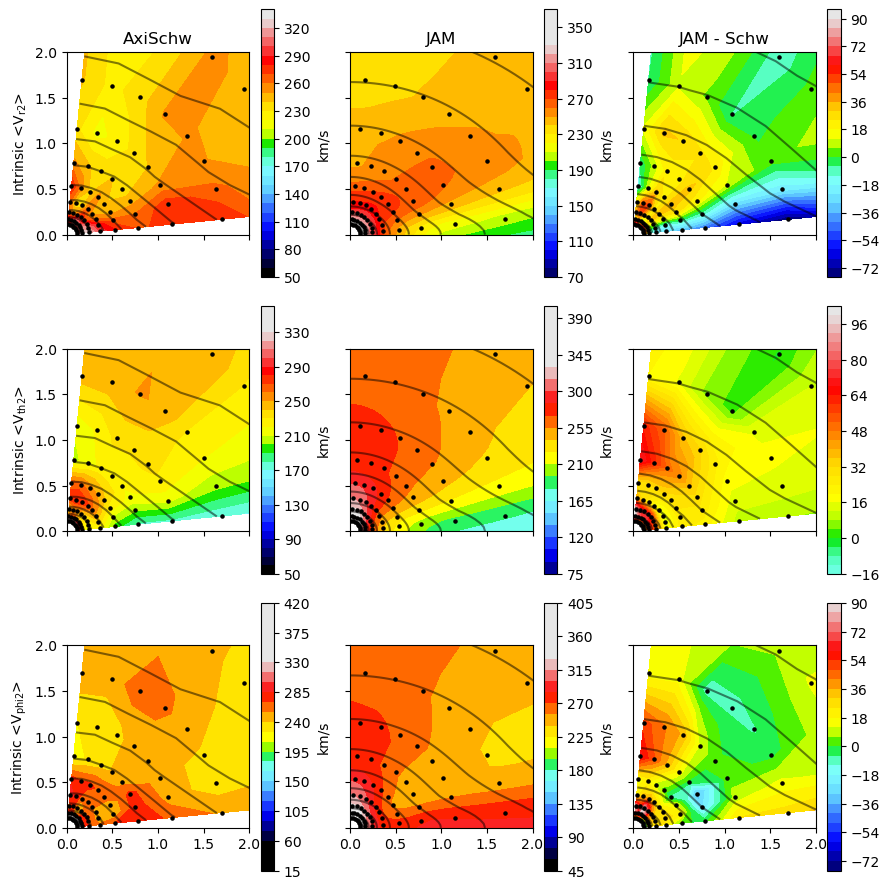

In [ ]:
import os, sys
os.chdir(os.path.expanduser('~/work/galactic_dynamics'))
sys.path.insert(0, 'JAM')
sys.path.insert(0, 'Axi_Schwarzschild/Schwarzschild')
print('CWD:', os.getcwd())

from shared_utils.jam_schw_compare import plot_2D_moment
from schwarzpy.model import read_nn_mer, read_ap
import numpy as np
import matplotlib.pyplot as plt
from jam_fit import JamInput, jam_model
from jam_fit.plot import plot_kinematics
from pathlib import Path

work_dir = Path('results/JAM/NGC4621-mock2/i75-cyl-fixaniso2-hist')
# work_dir = Path('results/JAM/NGC4621-mock-iso/i75-cyl-hist')
jam_config = JamInput(work_dir)

pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
pars_dict = jam_config.get_pars(pars)

aperture_file = jam_config.input_dir / 'aperture_o.dat'
nn_mer_file = jam_config.input_dir / 'nn_mer.out'
# nn_mer_file = '../Axi_Schwarzschild/data_prep/NGC4621-h4-0h6sdf2/datfil/nn_mer.out'
# work_dir = '/Users/haitongwang/Work/Axi_Schwarzschild/data_prep/NGC4621-h4-0h6sdf2'
# nn_mer_file = work_dir + '/datfil/nn_mer.out'
plot_2D_moment(nn_mer_file, aperture_file, aperture=25, jam_input=jam_config, pars_dict=pars_dict, moment_names=['r2', 'th2', 'phi2', 't2', 'total2'])
plt.show()

plot_2D_moment(nn_mer_file, aperture_file, aperture=2, jam_input=jam_config, pars_dict=pars_dict)
plt.tight_layout()
plt.show()

plot_2D_moment(nn_mer_file, aperture_file, aperture=2, jam_input=jam_config, pars_dict=pars_dict, show_ratio=True, moment_names=['th2'])
plt.tight_layout()
plt.show()

No is_good column in the data, set all bins to good.
(41,) (41, 618)
[0.99525012 8.44988317 0.45722692] {'q': 0.141, 'ratio': np.float64(0.9952501246784453), 'lg_mbh': np.float64(8.44988317010032), 'lg_ml': np.float64(0.4572269209751024), 'f_dm': 0.0, 'lg_rb': 3.0, 'sigma1': 0.36, 'sigma2': 0.92, 'weight1': 0.76, 'ratio_inf': 0.615, 'lg_ra': 1.425, 'lg_al': 0.3, 'lg_ml_inf': 0.462}


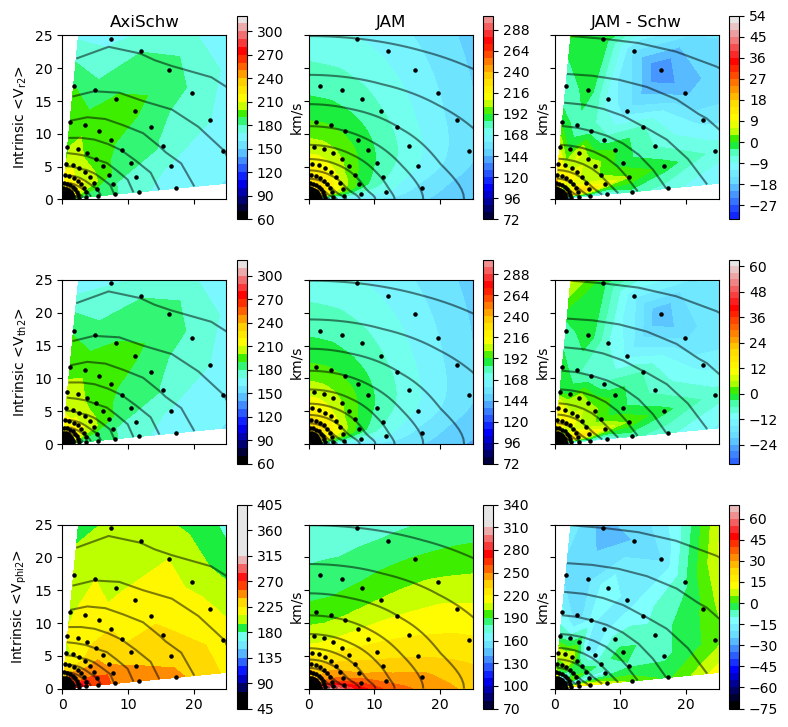

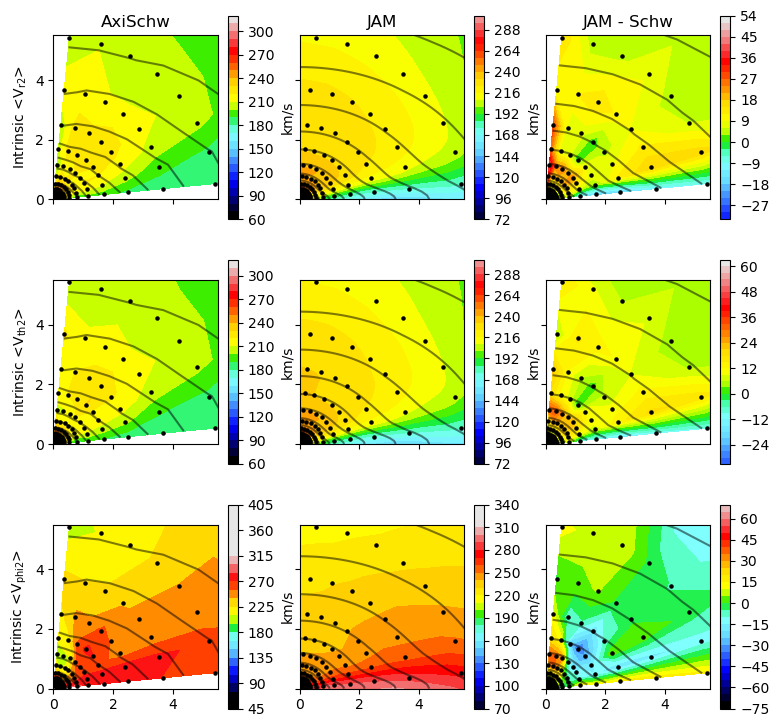

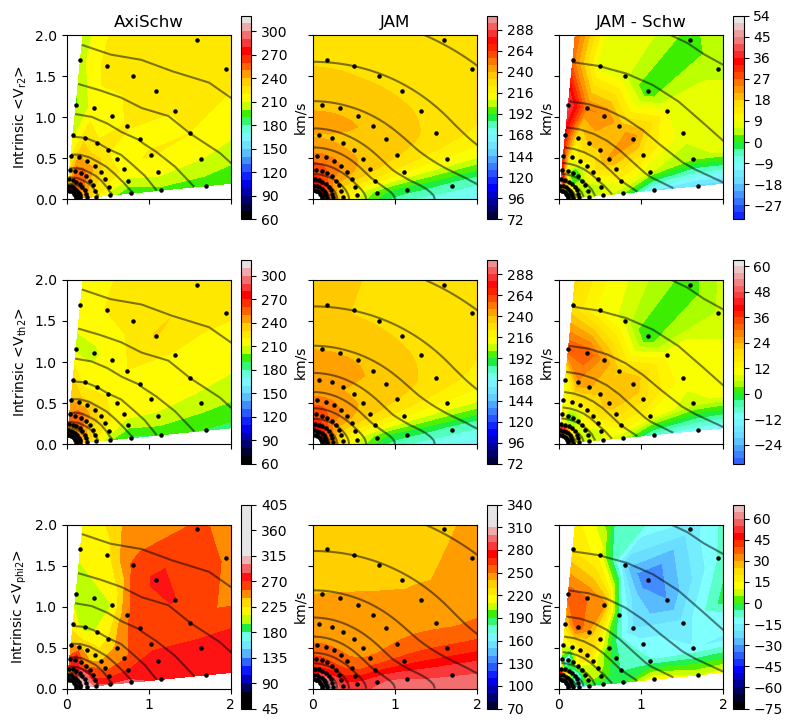

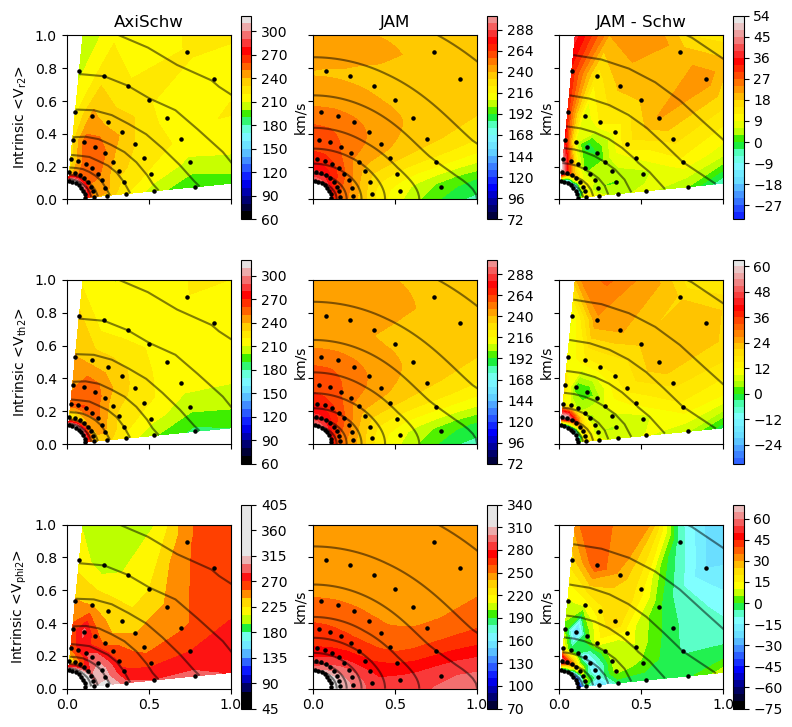

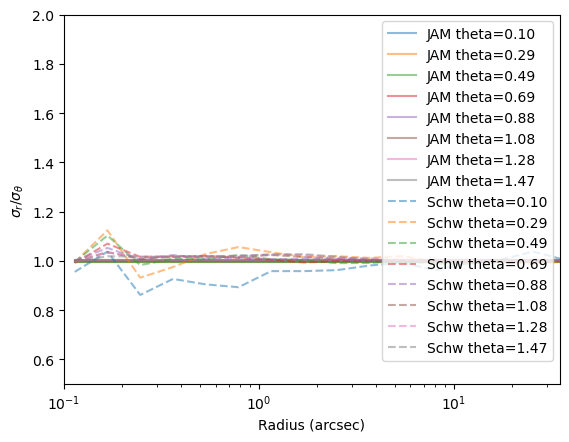

[0.99525012 8.44988317 0.45722692]
Reff: 54.34711014664929
17 17
0.04 154.88


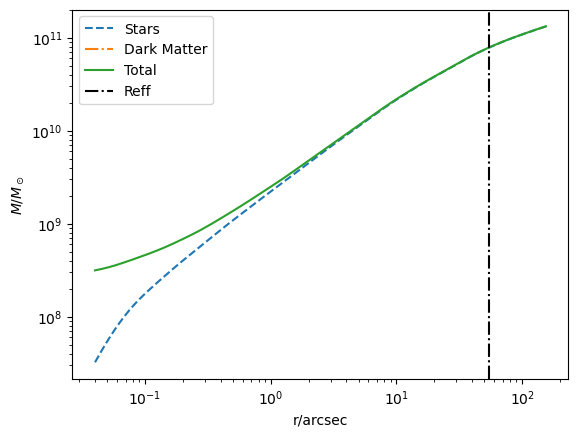

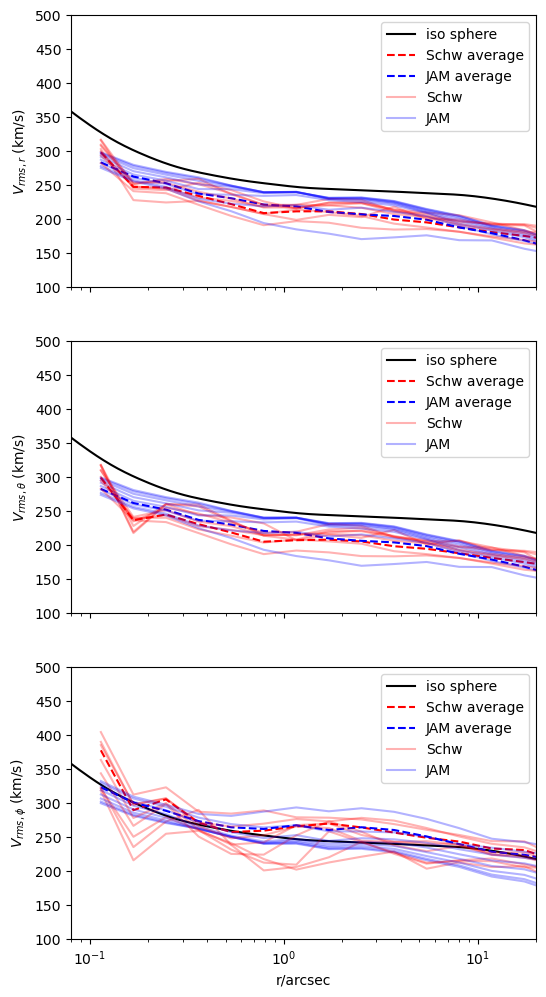

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from jam_fit import JamInput
from jam_fit.plot import plot_enclosed_mass
from pathlib import Path
from shared_utils.jam_schw_compare import plot_2D_moment

# work_dir = Path('results/JAM/NGC4621-mock2/i75-cyl-fixaniso2-hist')
work_dir = Path('results/JAM/NGC4621-mock-iso/i75-cyl-hist')
jam_config = JamInput(work_dir)

pars = np.loadtxt(work_dir / 'jam_bestfit.dat')
# pars = [8.43, 0.4485]
pars_dict = jam_config.get_pars(pars)
# pars_dict['lg_mbh'] = 8.43
# pars_dict['lg_ml'] = 0.4485
# pars_dict['ratio'] = 0.87
print(pars, pars_dict)

aperture_file = jam_config.input_dir / 'aperture_o.dat'
nn_mer_file = jam_config.input_dir / 'nn_mer.out'

# in_dir = 'input/NGC4621-mock'
# nn_mer_file = in_dir + '/nn_mer.out'

# moment_names = ['r2', 'th2', 'phi2sig', 'phi2', 't2', 'total2']
moment_names = ['r2', 'th2', 'phi2']
# moment_labels = [r'$\sigma_r$', r'$\sigma_\theta$', r'$\sigma_\phi$', r'$V_{rms,\phi}$', r'$V_{rms,t}$', r'$V_{rms,total}$']
moment_labels = [r'$V_{rms,r}$', r'$V_{rms,\theta}$', r'$V_{rms,\phi}$']

plot_2D_moment(nn_mer_file, aperture_file, aperture=25, jam_input=jam_config, pars_dict=pars_dict, moment_names=moment_names)
plt.show()

temp = plot_2D_moment(nn_mer_file, aperture_file, aperture=5.5, jam_input=jam_config, pars_dict=pars_dict, moment_names=moment_names)
R, TH, schw_moments, jam_moments, R_jam, TH_jam, jam_moments_intp = temp
plt.show()

plot_2D_moment(nn_mer_file, aperture_file, aperture=2, jam_input=jam_config, pars_dict=pars_dict, moment_names=moment_names)
plt.show()

plot_2D_moment(nn_mer_file, aperture_file, aperture=1, jam_input=jam_config, pars_dict=pars_dict, moment_names=moment_names)
plt.show()

sigma_r = np.sqrt(jam_moments['r2'])
sigma_th = np.sqrt(jam_moments['th2'])
anisotropy_ratio = sigma_r/sigma_th
for i in range(len(R[0])):
    plt.plot(R[:, i], anisotropy_ratio[:, i], label=f'JAM theta={TH[0, i]:.2f}', alpha=0.5, color=f'C{i}')

for i in range(len(R[0])):
    sigma_r_schw = np.sqrt(schw_moments['r2'][:, i])
    sigma_th_schw = np.sqrt(schw_moments['th2'][:, i])
    anisotropy_ratio_schw = sigma_r_schw/sigma_th_schw
    plt.plot(R[:, i], anisotropy_ratio_schw, label=f'Schw theta={TH[0, i]:.2f}', alpha=0.5, linestyle='--', color=f'C{i}')
plt.xlabel('Radius (arcsec)')
plt.ylabel(r'$\sigma_r/\sigma_\theta$')
plt.xscale('log')
plt.xlim(0.1, 35)
plt.ylim(0.5, 2)
plt.legend()
plt.show()

print(pars)
radi, stars_masses, dm_masses, total_masses = plot_enclosed_mass(jam_config, pars)

# plt.axvline(0.29, color='r', linestyle='-.', label='Rsoi')
# print(np.min(sigma_pot), np.max(sigma_pot))
print(np.min(jam_config.sigma), np.max(jam_config.sigma))
# plt.xlim([0.1*np.min(sigma_pot), 10*np.max(sigma_pot)])
# plt.ylim([2E-2,2E6])
plt.show()

import astropy.constants as const
import astropy.units as u
radi_pc = (radi*u.arcsec*jam_config.dist*u.Mpc/u.radian).to(u.pc)
vcirc = np.sqrt(total_masses*u.Msun*const.G/(radi_pc)/2).to(u.km/u.s).value

fig, axes = plt.subplots(len(moment_names), 1, figsize=(6, 4*len(moment_names)), sharex=True)
for i in range(len(moment_names)):
    moment_name = moment_names[i]
    moment_label = moment_labels[i]
    ax = axes[i]
    ax.plot(radi, vcirc, label='iso sphere', color='k')
    schw_m = schw_moments[moment_name]
    jam_m = jam_moments[moment_name]
    schw_m_average = np.average(schw_m, axis=1, weights=schw_moments['mass'])
    jam_m_average = np.average(jam_m, axis=1, weights=jam_moments['mass'])

    ax.plot(R[:, 0], np.sqrt(schw_m_average), label='Schw average', color='r', linestyle='--')
    ax.plot(R[:, 0], np.sqrt(jam_m_average), label='JAM average', color='b', linestyle='--')

    alpha = 0.3
    for i in range(len(R[0])):
        if i == 0:
            ax.plot(R[:, i], np.sqrt(schw_m[:, i]), alpha=alpha, color='r', linestyle='-', label='Schw')
            ax.plot(R[:, i], np.sqrt(jam_m[:, i]), alpha=alpha, color='b', linestyle='-', label='JAM')
        else:
            ax.plot(R[:, i], np.sqrt(schw_m[:, i]), alpha=alpha, color='r', linestyle='-')
            ax.plot(R[:, i], np.sqrt(jam_m[:, i]), alpha=alpha, color='b', linestyle='-')
        
    ax.set_xscale('log')
    ax.set_ylabel(moment_label + ' (km/s)')
    ax.set_ylim(100, 500)
    ax.set_xlim(0.08, 20)
    ax.legend()
plt.xlabel('r/arcsec')
plt.show()

